In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="darkgrid")  # styling


In [4]:
df = pd.read_csv("PandasTitanic_cleaned.csv")
df.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,FamilySize
0,1,0,3,"Braund, Mr. Owen Harris",male,-0.101401,1,0,A/5 21171,-0.502445,S,2
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,0.808338,1,0,PC 17599,0.786845,C,2
2,3,1,3,"Heikkinen, Miss. Laina",female,0.126034,0,0,STON/O2. 3101282,-0.488854,S,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,0.637762,1,0,113803,0.420730,S,2
4,5,0,3,"Allen, Mr. William Henry",male,0.637762,0,0,373450,-0.486337,S,1


In [12]:
df.shape            # (rows, columns)



(891, 12)

In [13]:
df.info()           # Column types, null values


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          891 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Embarked     889 non-null    object 
 11  FamilySize   891 non-null    int64  
dtypes: float64(2), int64(6), object(4)
memory usage: 83.7+ KB


In [14]:
df.describe()       # Numerical stats like mean, std


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare,FamilySize
count,891.000000,891.000000,891.000000,8.910000e+02,891.000000,891.000000,8.910000e+02,891.000000
mean,446.000000,0.383838,2.308642,1.594933e-17,0.523008,0.381594,2.791133e-17,1.904602
std,257.353842,0.486592,0.836071,1.000562e+00,1.102743,0.806057,1.000562e+00,1.613459
min,1.000000,0.000000,1.000000,-1.352292e+00,0.000000,0.000000,-6.484217e-01,1.000000
25%,223.500000,0.000000,2.000000,-1.011140e+00,0.000000,0.000000,-4.891482e-01,1.000000
50%,446.000000,0.000000,3.000000,1.231619e-02,0.000000,0.000000,-3.573909e-01,1.000000
75%,668.500000,1.000000,3.000000,6.377616e-01,1.000000,0.000000,-2.424635e-02,2.000000
max,891.000000,1.000000,3.000000,3.196402e+00,8.000000,6.000000,9.667167e+00,11.000000


In [15]:
df.columns          # Saare columns ke naam


Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Embarked', 'FamilySize'],
      dtype='object')

In [16]:
df.nunique()        # Har column me unique values kitni

PassengerId    891
Survived         2
Pclass           3
Name           891
Sex              2
Age             71
SibSp            7
Parch            7
Ticket         681
Fare           248
Embarked         3
FamilySize       9
dtype: int64

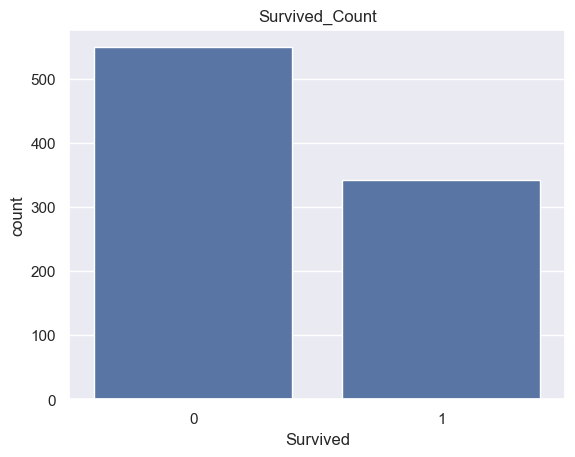

In [7]:
df['Survived'].value_counts()
sns.countplot(x='Survived', data=df)
plt.title("Survived_Count")
plt.show()

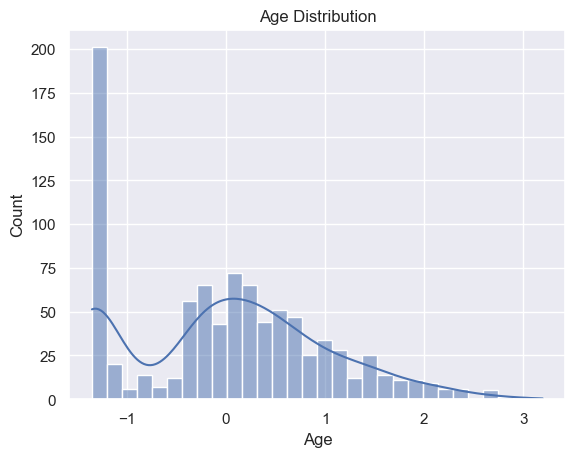

In [13]:
sns.histplot(df['Age'], bins=30, kde=True)  # Histogram + KDE for Age
plt.title("Age Distribution")               # Title
plt.show()

  

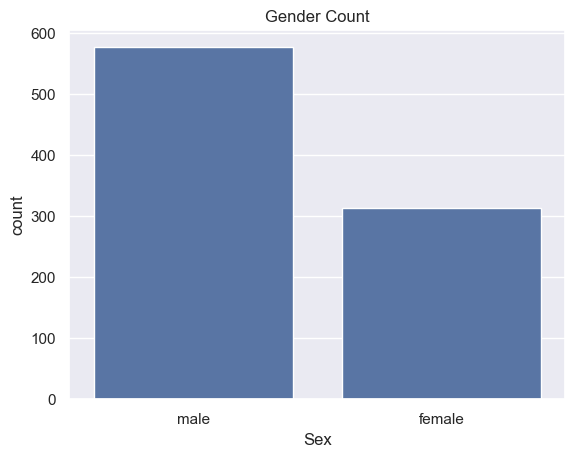

In [16]:
sns.countplot(x='Sex', data=df)             # Gender wise count bar chart
plt.title("Gender Count")
plt.show()


 Step 5: Bivariate Analysis – Do Columns

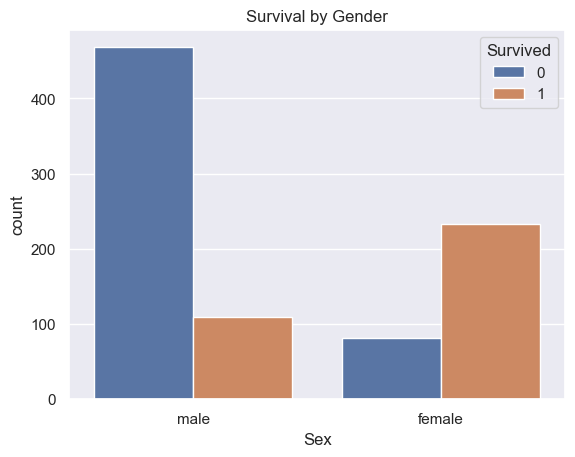

In [17]:
sns.countplot(x='Sex',hue='Survived',data=df)
plt.title("Survival by Gender")
plt.show()

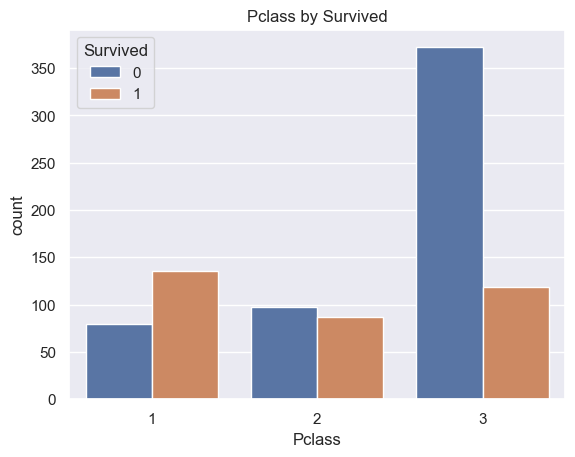

In [21]:
sns.countplot(x='Pclass',hue='Survived', data=df)
plt.title("Pclass by Survived")
plt.show()

C:\Users\HARSHIT SHARMA\AppData\Local\Temp\ipykernel_12592\2995414334.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset['Sex'] = subset['Sex'].map({'male': 0, 'female': 1})


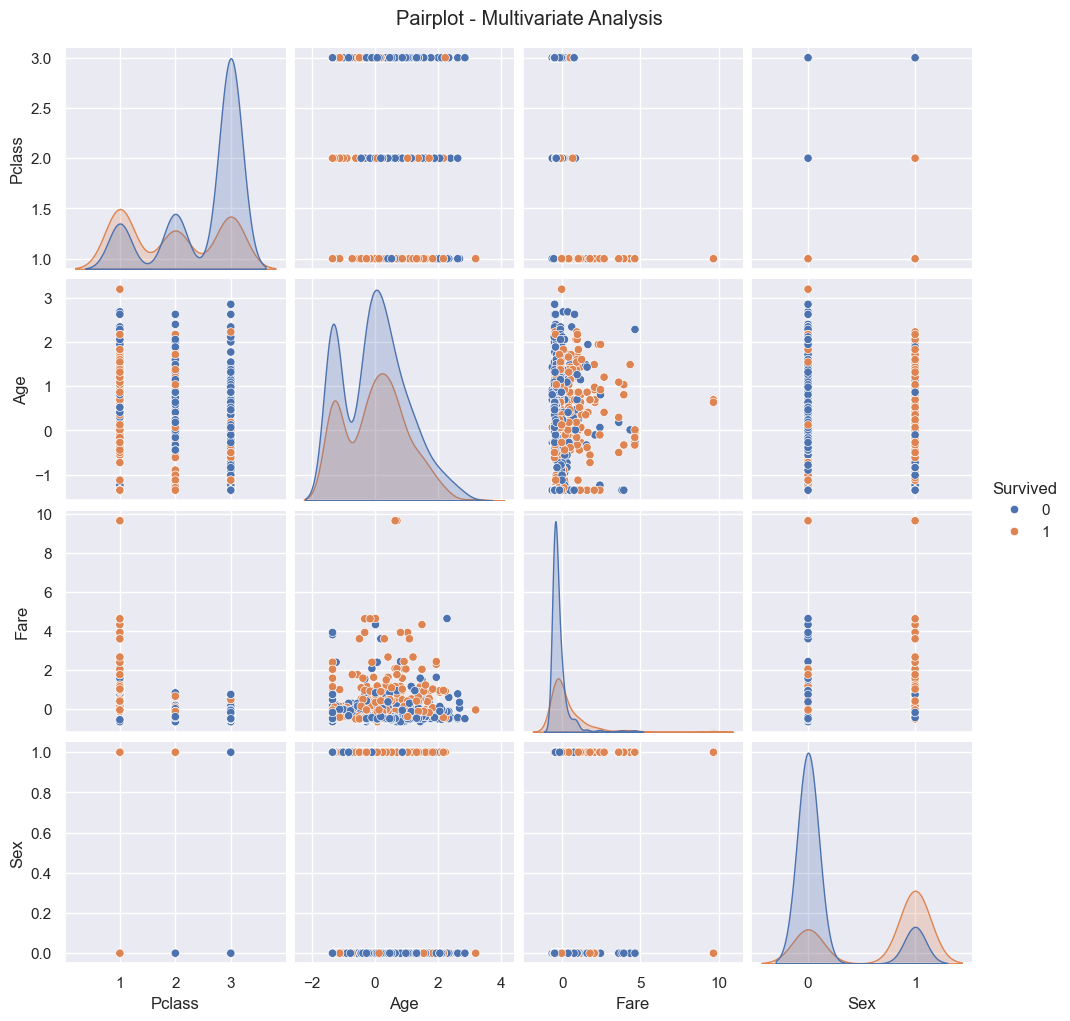

In [24]:

# Subset bana lo with selected columns
# yaha 'Survived' target variable hai (hue ke liye), baaki features de rahe hain
subset = df[['Survived', 'Pclass', 'Age', 'Fare', 'Sex']]

# Sex ko encode karna hoga (kyunki pairplot numerical data ke saath kaam karta hai)
subset['Sex'] = subset['Sex'].map({'male': 0, 'female': 1})

# Pairplot banate hain
sns.pairplot(subset, hue='Survived')
plt.suptitle("Pairplot - Multivariate Analysis", y=1.02)
plt.show()



In [25]:
print(df.groupby('Sex')['Survived'].mean())      # Gender-wise average survival rate
print(df.groupby('Pclass')['Survived'].mean())   # Class-wise average survival rate


Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64
Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64


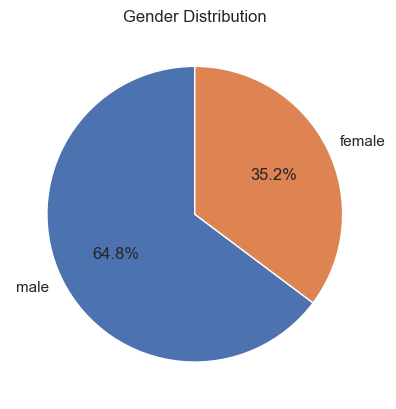

In [26]:
df['Sex'].value_counts().plot.pie(autopct='%1.1f%%', startangle=90)  
plt.title("Gender Distribution")
plt.ylabel("")        
plt.show()


## 📊 EDA Summary: Titanic Dataset

### 🔹 Dataset Overview
- Total **891 rows** and **12 columns**.
- Dataset included details like Name, Age, Gender, Ticket Class, Fare, and Survival status.

### 🔹 Missing Values
- Columns with missing data: `Age`, `Cabin`, `Embarked`.
- `Cabin` dropped due to excessive missing values.
- `Age` filled with median, `Embarked` filled with mode.

### 🔹 Univariate Analysis
- **Survival Rate**: Around **38%** passengers survived.
- **Gender Distribution**: More **males** onboard, but **females survived more**.
- **Age Distribution**: Most passengers were **15–35 years old**.
- **Pclass**: Majority of passengers belonged to **3rd class**.

### 🔹 Bivariate & Multivariate Insights
- **Sex vs Survived**: 
  - Female survival ~74%
  - Male survival ~19%
- **Pclass vs Survived**: 
  - 1st class had highest survival rate.
- **Heatmap**:
  - Moderate **negative correlation** between `Pclass` and `Survived`
  - Positive correlation between `Fare` and `Survived`

### 🔹 Visualizations Used
- **Bar Plot** for gender distribution and survival
- **Histogram** for age
- **Pie Chart** for gender percentage
- **Heatmap** for correlation between numerical variables



### ✅ Conclusion
Data has been **cleaned, visualized, and key patterns extracted**.  
**Gender**, **Class**, and **Fare** are strong indicators of survival.  
Dataset is now ready for **modeling or machine learning** tasks.

Prepared by: Harshit Sharma 
